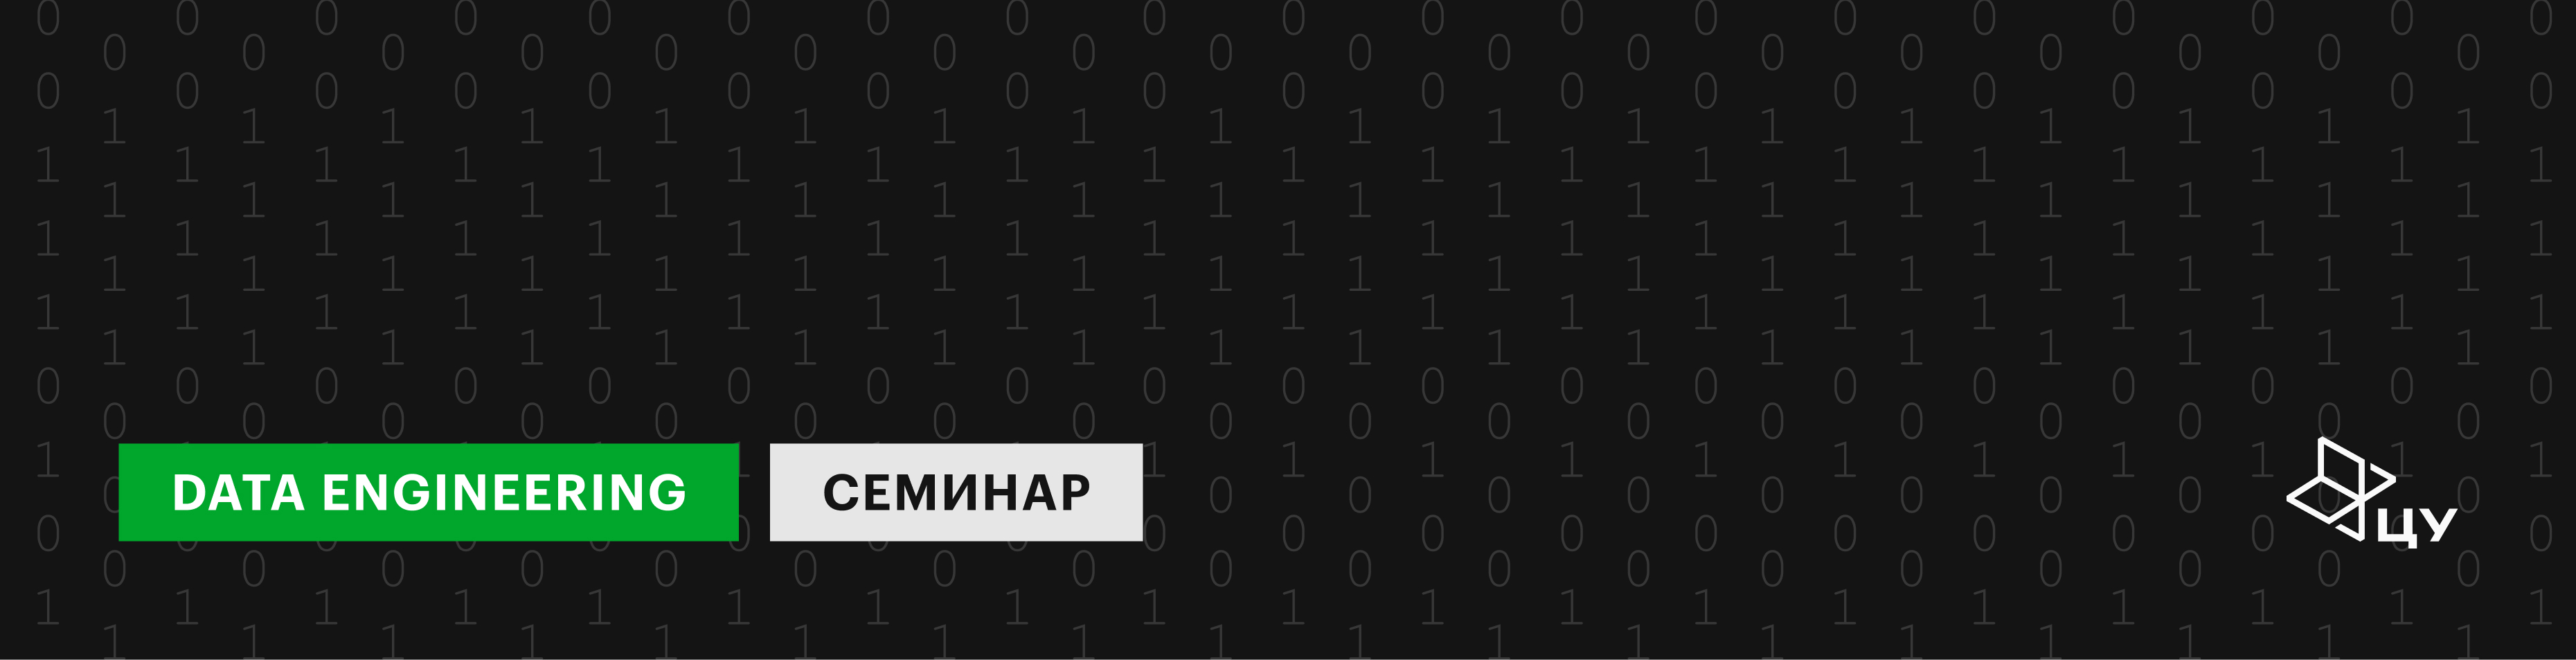

# Семинар по теме Введение в инженерию данных. Профессия и основные концепции

**Добро пожаловать на практическое занятие!**

## Семинар 1. Основы работы с файловыми хранилищами.




Для начала работы с ноутбуком запусти первую ячейку.

In [ ]:
%pip install duckdb-extensions duckdb-extension-httpfs
from duckdb_extensions import import_extension;import duckdb;import_extension("httpfs")
con = duckdb.connect();con.execute("LOAD httpfs;")
import os,requests,time,pandas as pd,yaml;u="http://sql-exercise.sql-exercise-prod.svc.cluster.local/";f="py_workshop.py"
if os.path.exists(f):os.remove(f)
if not os.path.exists(f):
    r=requests.get(u+"get_py_workshop");r.status_code==200 and open(f,"wb").write(r.content) and time.sleep(1)
from py_workshop import *;runner.set_url(u);runner.logon();schema_name = runner.user_schema;config = runner.get_config()
pd.set_option("display.max_columns", None);pd.set_option("display.width", 2000);pd.set_option("display.max_colwidth", None);pd.set_option("display.max_rows", None)
runner.course = 'de'
runner.material( 'de_intro_p', course_launch='de_2026_fall_cu')

## Цель семинара
Изучить основы работы с S3, boto3, AWS CLI и DuckDB на практике:
- получить доступ к данным в облачном хранилище,
- скачивать и загружать данные,
- анализировать данные и формировать аналитические выводы.


В семинаре используется источник со сгенерированными данными об авиарейсах.


Рассмотрим учебный сценарий: аналитической команде авиакомпании необходимо определить маршруты, на которых чаще всего возникают задержки. Данные хранятся в S3; их требуется скачать, проанализировать и выделить маршруты с наибольшей долей задержек.


## Что делает дата-инженер?

Дата-инженер работает с большими объемами данных, которые хранятся в облаке. Первый шаг — определить, какие данные доступны в источнике.

## Используемые инструменты


- S3 — объектное хранилище для размещения файловых данных.
- boto3 — Python SDK для работы с AWS-совместимыми сервисами.
- AWS CLI — инструмент командной строки для работы с AWS-совместимыми сервисами.
- DuckDB — встраиваемая аналитическая база данных для работы с локальными файлами и данными в памяти.



## Подготовка перед выполнением заданий

Получи ключи для доступа к учебному бакету в S3-like-хранилище с помощью кнопки Настройка. Если не получается сгенерировать ключи, обратись к преподавателю. Можно также проверить доступность self-service https://self-service.culab.ru.

В канале ~it-support-students помогут устранить системные проблемами. Например, недоступность адресов серверов.

In [ ]:
# настрой профиль common — для чтения общего бакета
!aws configure set aws_access_key_id "{config['s3_public']['login']}" --profile common
!aws configure set aws_secret_access_key "{config['s3_public']['password']}" --profile common
!aws configure set region "ru-central1" --profile common

**Важно:** эти учётные данные будут использоваться во всех примерах ниже для подключения к S3.


## Получение исходных данных из S3-совместимого хранилища

### Скачивание нескольких файлов по маске

В воркшопе был рассмотрен пример скачивания одного файла. В семинаре рассматривается скачивание нескольких файлов с общим префиксом.

Требуется скачать все файлы за предыдущую дату из общего бакета `culab-files-prod`.

Источник данных: `ds_avia_sim_ru`. Данные являются сгенерированными.

Сначала необходимо просмотреть, какие файлы существуют в хранилище.

In [ ]:
files = !aws s3 ls s3://culab-files-prod/files/public/data_engineering/data_streams/ds_avia_sim_ru/ \
--recursive \
--endpoint=https://storage.yandexcloud.net \
--profile common

files[-10:]

### Задача 1. Скачивание данных из S3




Требуется скачать файлы из общего источника S3.

Целевая папка для сохранения данных — `./flights_ru_today`.

Дополни заготовку в ячейке ниже.

In [ ]:
%%py_code_local cell_1_1
# Задача 1. Ячейка 1. удаление папки

# Пересоздаём папку, чтобы повторный запуск не смешивал старые и новые файлы
!rm -rf <папка>
!mkdir -p <папка>


Теперь дополни заготовку команды `aws s3 cp <откуда> <куда> ...` в ячейке ниже.

In [ ]:
%%py_code_local cell_1_2
# Задача 1. Ячейка 2. загрузка файлов

!aws s3 cp s3://culab-files-prod/files/public/data_engineering/data_streams/ds_avia_sim_ru/<YYYY-MM-DD>/ \
<папка>/ \
--recursive \
--exclude "*" \
--include "*.csv" \
--endpoint=https://storage.yandexcloud.net \
--profile common

print("Готово")


Затем выполни `ls` для проверки содержимого локальной папки. Команда уже добавлена в ячейку ниже.


**Пояснения**
- `--recursive` — рекурсивно обходит все файлы в папке.
- `--exclude "*"` — сначала исключаем все файлы.
- `--include "*.csv"` — затем включаем все файлы csv с заданным префиксом.

**Результат:** в папке `./flights_ru_today/` появятся все файлы за выбранную дату.

In [ ]:
%%py_code_local cell_1_3
# Задача 1. Ячейка 3. проверка содержимого

!ls -lh ./flights_ru_today/




### Поиск доступных файлов за один день

Далее необходимо выгрузить данные за последние три дня в одну локальную папку.

Перед скачиванием целесообразно сначала определить, какие файлы доступны в источнике.

Для этой задачи в boto3 используется функция `list_objects_v2`. Если объектов больше 1000, в промышленном коде следует использовать `get_paginator`.

### Задача 2. Чтение списка файлов




Используй заготовку в ячейке ниже, чтобы подготовить папку и подключиться к S3.

In [ ]:
%%py_code_local cell_2_1
# Задача 2. Ячейка 1. Удаление файлов из папки

import boto3
from datetime import datetime, timedelta

# Пересоздаём папку, чтобы повторный запуск не смешивал старые и новые файлы
!rm -rf ./flights_ru_today/
!mkdir -p ./flights_ru_today/

# Подключаемся к S3
s3_client = boto3.client(
    's3',
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=config['s3_public']['login'],
    aws_secret_access_key=config['s3_public']['password'],
)


Заготовка в следующей ячейке получает список файлов в S3 с заданным префиксом. Для нашего курса важен не синтаксис Python, а применение функций, таких как `list_objects_v2`.

In [ ]:
%%py_code_local cell_2_2
# Задача 2. Ячейка 2. Получение списка файлов

# Получаем список всех файлов в папке (с заданным префиксом)
response = s3_client.list_objects_v2(
    Bucket="culab-files-prod",
    Prefix='files/public/data_engineering/data_streams/ds_avia_sim_ru/<дата>/'
)

len(response['Contents'])



Названия файлов можно выбрать из полученного ответа с помощью заготовки в следующей ячейке.

Выведи имена файлов, которые соответствуют заданному пути. В S3 нет папок: «каталог» в данном случае является префиксом в ключе объекта.

In [ ]:
%%py_code_local cell_2_3
# Задача 2. Ячейка 3. Вывод имён файлов

files = []
if 'Contents' in response:
    for obj in response['Contents']:
        filename = obj['Key'].split('/')[-1]  # Получаем только имя файла
        files.append(filename)
        print(f"  📄 {filename} ({obj['Size']} bytes)")

print(f"\n📊 Всего найдено файлов: {len(files)}")



### Выбор авиарейсов за последние 3 дня

Далее нужно выбрать файлы за несколько дней и сохранить их в локальную папку.

### Задача 3. Чтение списка файлов за последние 3 дня





Требуется получить список всех файлов за последние три дня. Дополни заготовку в соответствующей ячейке ниже.

In [ ]:
%%py_code_local cell_3_1
# Задача 3. Ячейка 1. Очистка

!rm -rf ./flights_ru_today/
!mkdir -p ./flights_ru_today/


In [ ]:
%%py_code_local cell_3_2
# Задача 3. Ячейка 2. Получение списка файлов за последние 3 дня

files = [] # файлы
for i in range(3):
    date = (datetime.now() - timedelta(days=i)).strftime('%Y-%m-%d')
    response = s3_client.list_objects_v2(
        Bucket="<бакет>",
        Prefix=f'files/public/data_engineering/data_streams/ds_avia_sim_ru/2026-07-01'
    )

    if 'Contents' in response:
        for obj in response['Contents']:
            filename = obj['Key']  # Получаем ключи
            files.append(filename)

print(f"\n📊 Всего найдено файлов: {len(files)}")


После получения списка файлов скачай каждый из них в папку `./flights_ru_today/`, используя заготовку в ячейке ниже.

In [ ]:
%%py_code_local cell_3_3
# Задача 3. Ячейка 3. Скачивание файлов

downloaded_count = 0
for file in files:
    key = file
    local_file = f"./<локальная папка>/{file.split('/')[-1]}"   # Получаем только имя файла

    try:
        s3_client.download_file(
            Bucket="culab-files-prod",
            Key=<ключ>,
            Filename=local_file
        )
        downloaded_count += 1
        print(f"  ✅ {key} - скачан")
    except Exception as e:
        print(f"  ⚠️  {key} - не найден: {e}")

print(f"\n✅ Всего скачано файлов: {downloaded_count}")



Получилось много файлов. Как их теперь можно обработать?

## Обработка файлов с помощью SQL в DuckDB

### Чтение схемы данных

Будем использовать `describe`, чтобы определить схему данных в файлах csv.

Используем `DuckDB` для чтения и анализа данных, сохранённых в локальной папке. Эта СУБД поддерживает SQL.

DuckDB не требует сложной установки специального программного обеспечения.

Для чтения из нескольких файлов используй знак `*` в имени файла. Табличная функция `read_csv_auto(путь или шаблон пути)` автоматически определяет типы данных.

С помощью `describe select` можно получить информацию о схеме данных.

### Задача 4. Применение DuckDB для чтения схемы файлов




Требуется получить схему данных ранее скачанных файлов за 3 дня. Дополни заготовку в ячейке ниже.

Здесь можно записать имя отдельного файла или задать маску. Например, `./flights_data/flights_*.csv`

In [ ]:
%%py_code_local cell_4_1
# Задача 4. Ячейка 1. Код DuckDB

con.execute(f"""
    describe select
        *
    FROM
        read_csv_auto('<шаблон локального имени>')
""").df()




### Чтение данных из нескольких файлов

В этой части мы будем использовать SQL для чтения и обработки данных.

### Задача 5. Запросы к файлам через DuckDB





DuckDB может автоматически объединять несколько файлов перед обработкой.

Требуется написать один SQL-запрос, который находит количество строк в скачанных файлах.

In [ ]:
%%py_code_local cell_5_1
# Задача 5. Ячейка 1. Код с DuckDB



### Подсчёт числа рейсов по дням

Проанализируем, сколько рейсов было отправлено каждый день.

### Задача 6. Агрегация данных





DuckDB поддерживает запросы с агрегирующими функциями, такими как sum, count, avg, min, max. Функции, такие как date_trunc, тоже можно использовать. Приведение типов тоже поддерживается.

Можно использовать `выражение::тип` для конвертации типов данных.

Требуется написать один SQL-запрос, который подсчитывает количество строк в скачанных файлах. Результат должен содержать два столбца: дату отправки `dt` и количество рейсов `flights_count`. Заготовка запроса находится в ячейке ниже.

In [ ]:
%%py_code_local cell_6_1
# Задача 6. Ячейка 1. Запрос DuckDB

con.execute(f"""
select
    departure_time::date dt,
    count(*) as flights_count,
FROM
    read_csv_auto('./flights_ru_today/avia_ru_*.csv')
    group by 1
""").df()


### Подсчёт числа рейсов по дням и аэропортам и сохранение результата в файл

Сформируй расширенный набор данных с учётом аэропорта вылета.

Результат выполнения запроса необходимо сохранить в CSV-файл. 

### Дополнительная задача 7. Сохранение результата запроса в файл





Требуется сохранить результат запроса, который возвращает количество рейсов по дням и аэропортам вылета. Результат должен содержать следующие столбцы:
- `dt` — дата вылета;
- `departure_airport` — аэропорт вылета;
- `flights_count` — количество рейсов.

Заготовка запроса находится в ячейке ниже.

In [ ]:
%%py_code_local cell_7_1
# Задача 7. Ячейка 1. Запрос

con.execute(f"""
select
    departure_time::date dt,
    departure_airport,
    count(*) as flights_count,
FROM
    read_csv_auto('./flights_ru_today/avia_ru_*.csv')
    group by 1, 2
""").df()


Сохрани данные в файл `airport_stats.csv` с помощью `df.to_csv('airport_stats.csv', index=False)`.

In [ ]:
%%py_code_local cell_7_2
# Задача 7. Ячейка 2. Сохранение в csv локально

df.to_csv('airport_stats.csv', index=False)


## Загрузка результатов анализа в S3


Далее результат анализа необходимо загрузить в персональное S3-хранилище.

Для записи доступен S3-бакет `culab-student-files`.

После загрузки результат анализа можно читать напрямую из S3.

Для записи в бакет `culab-student-files` используется отдельное подключение с персональными ключами. Заготовка создаст клиент для этого подключения.

Для обращения к бакету из DuckDB также необходимо задать параметры подключения. Эта заготовка будет добавлена в задачу чтения файла из S3.

### Дополнительная задача 8. Отправка файла в персональный бакет




Загрузи данные в персональный бакет S3.

Дополни заготовку в ячейке ниже.

In [ ]:
%%py_code_local cell_8_1
# Задача 8. Ячейка 1. Отправка данных в S3

# Подключение
s3_client_my = boto3.client(
    's3',
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=config['s3_my']['login'],
    aws_secret_access_key=config['s3_my']['password'],
)

# Загружаем результаты в S3
s3_client_my.upload_file(
    Filename='airport_stats.csv',
    Bucket="culab-student-files",
    Key=f'users/{schema_name}/de_intro/airport_stats.csv'
)

print("✅ Результаты анализа загружены в S3!")


После загрузки проверь наличие файла в хранилище с помощью заготовки в ячейке ниже.

In [ ]:
%%py_code_local cell_8_2
# Задача 8. Ячейка 2. Проверка списка файлов

# Проверим, есть ли файл
response = s3_client_my.list_objects_v2(
    Bucket="culab-student-files",
    Prefix=f'users/{schema_name}/de_intro/'
)

response['Contents']


### Дополнительная задача 9. Обращение к файлу в S3




Файл с результатами расчётов находится в персональном бакете S3 по ключу `users/{schema_name}/de_intro/airport_stats.csv`. В коде используй переменную `schema_name`. С помощью DuckDB необходимо обратиться к этим данным и вывести статистику аэропорта DME.
- dt Дата отправления
- flights_count Количество полётов

В качестве пути к файлу используй `s3://culab-student-files/users/{schema_name}/de_intro/airport_stats.csv`. Заготовки настройки DuckDB и запроса находятся в ячейках ниже.


In [ ]:
%%py_code_local cell_9_1
# Задача 9. Ячейка 1. Запрос через DuckDB

# Настраиваем доступ к S3 в DuckDB
con.execute(f"""
    SET s3_region='ru-central1';
    SET s3_endpoint='storage.yandexcloud.net';
    SET s3_access_key_id='{config['s3_my']['login']}';
    SET s3_secret_access_key='{config['s3_my']['password']}';
    SET s3_use_ssl=true;
    SET s3_url_style='path';
""")


In [ ]:
%%py_code_local cell_9_2
# Задача 9. Ячейка 2. Запрос к файлу в S3

con.execute(f"""select
    dt,
    count(*) as flights_count
FROM
    read_csv_auto('s3://culab-student-files/users/{schema_name}/de_intro/airport_stats.csv')
    group by 1""").df()


# QR-код для сбора обратной связи

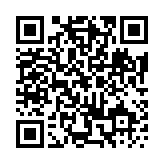